# Reproducibility Tutorial: Downscaling the Turc Agricultural Index
[![R](https://img.shields.io/badge/Language-R-blue.svg)]()
[![Deep Learning](https://img.shields.io/badge/Method-DeepESD-orange.svg)]()

**Pablo Lavin, Rodrigo Manzanas**

## Context and Introduction

Welcome to the reproducibility notebook for evaluating agricultural potential under climate change. 
In this tutorial, we skip the computationally expensive training phase. Instead, we will:
1. Load a **pre-trained DeepESD (CNN) model**.
2. Load historical and future climate data from a Global Climate Model (GCM) under the **RCP8.5 scenario**.
3. Apply **Scaling Delta Mapping** for bias correction.
4. Generate and visualize future projections for a specific **Global Warming Level (GWL)**.

### Prerequisites
Before starting, ensure you have downloaded the following sample files (https://drive.google.com/drive/folders/1LkjT7jT0MrvvO7yuQ4vnWGHWsrh-jG9q?usp=sharing):
* `model_DeepESD.h5` (Pre-trained Keras model)
* `GCM_data_MPI-ESM-MR.rds` (Sample GCM data)
* `xT_multigrid_ERA5_daily_1981_2020.rds` (ERA5 reference grid for bias correction)
* `y_template.rds` (Template of predictand for the structure of Keras)

## 0. Final Environment Configuration (Run Only Once)

Before we start loading models and making projections, we need to finalize our R environment. While Mamba handled our Python dependencies (TensorFlow/Keras) and base R packages, we still need to bridge the gap between R and Python, and install our specialized climate tools.

In this notebook, we will use **[climate4R](https://github.com/SantanderMetGroup/climate4R)**, an R-based framework designed for transparent and reproducible climate data access, post-processing, and visualization. Through its core bundle of packages (such as `loadeR`, `transformeR`, and `downscaleR`), this tool allows us to efficiently handle observations, reanalysis, and climate projections (using both gridded and station data), facilitating advanced tasks like bias correction and statistical downscaling. For more details on the framework, please refer to the main reference paper by [Iturbide et al. (2019)](https://doi.org/10.1016/j.envsoft.2018.09.009).

This setup cell does three things:
1. **Installs `remotes`:** A lightweight tool to download packages directly from GitHub.
2. **Installs R bindings:** Sets up the R interfaces for Keras and TensorFlow so they can communicate with our Conda environment.
3. **Installs `climate4R`:** Downloads the official climate downscaling ecosystem directly from the Santander Meteorology Group's GitHub repository.

> **IMPORTANT:** You only need to run this cell **once**. Once the packages are installed in your environment, you can skip this step in future sessions. Note that the full download takes a few minutes.

In [1]:
# INSTALL 'REMOTES' (Lightweight tool to install from GitHub)
if (!requireNamespace("remotes", quietly = TRUE)) {
    install.packages("remotes", repos = "http://cran.us.r-project.org")
}

# INSTALL KERAS AND TENSORFLOW R BINDINGS
if (!requireNamespace("keras", quietly = TRUE)) {
    install.packages("keras", repos = "http://cran.us.r-project.org")
}
if (!requireNamespace("tensorflow", quietly = TRUE)) {
    install.packages("tensorflow", repos = "http://cran.us.r-project.org")
}

# INSTALL THE CLIMATE4R ECOSYSTEM FROM GITHUB
# Using 'remotes' instead of 'devtools' for a cleaner, faster installation
remotes::install_github(c(
    "SantanderMetGroup/loadeR.java", 
    "SantanderMetGroup/loadeR", 
    "SantanderMetGroup/transformeR", 
    "SantanderMetGroup/visualizeR", 
    "SantanderMetGroup/downscaleR", 
    "SantanderMetGroup/downscaleR.keras"
))

message("Installation completed successfully!")

also installing the dependencies ‘ps’, ‘backports’, ‘config’, ‘processx’, ‘tfautograph’, ‘rstudioapi’, ‘whisker’, ‘tensorflow’, ‘tfruns’, ‘zeallot’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Using GitHub PAT from the git credential store.




rJava (NA -> 1.0-18) [CRAN]


Installing 1 packages: rJava

Warning message in i.p(...):
“installation of package ‘rJava’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Running `R CMD build`...



* checking for file ‘/tmp/Rtmp1NF6Lv/remotes2967569c2279/SantanderMetGroup-loadeR.java-486e29a/DESCRIPTION’ ... OK
* preparing ‘loadeR.java’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘loadeR.java_1.2.2.tar.gz’


Warning message in i.p(...):
“installation of package ‘/tmp/Rtmp1NF6Lv/file29675133e373/loadeR.java_1.2.2.tar.gz’ had non-zero exit status”



...

Installing 9 packages: iterators, codetools, survival, shape, foreach, sticky, evd, glmnet, deepnet

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Running `R CMD build`...



* checking for file ‘/tmp/Rtmp1NF6Lv/remotes29672c950769/SantanderMetGroup-downscaleR-6e8f200/DESCRIPTION’ ... OK
* preparing ‘downscaleR’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘downscaleR_3.3.4.tar.gz’


Running `R CMD build`...



* checking for file ‘/tmp/Rtmp1NF6Lv/remotes29673a79dff2/SantanderMetGroup-downscaleR.keras-9af9628/DESCRIPTION’ ... OK
* preparing ‘downscaleR.keras’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘downscaleR.keras_1.1.1.tar.gz’


Installation completed successfully!



## 1. Setup Python Environment and Load Pre-trained Model
Since `downscaleR.keras` bridges R and Python, we need to point `reticulate` to our Conda environment where TensorFlow is installed.

In [15]:
options(java.parameters = "-Xmx8g") # Allocate RAM for climate4R

# Point to your Conda environment Python executable
# UPDATE THIS PATH to match your local setup
Sys.setenv(RETICULATE_PYTHON = "/home/lavinp/miniforge3/envs/turc-downscaling/bin/python3.10")

# Load necessary libraries
library(reticulate)
library(tensorflow)
library(keras)
library(transformeR)
library(downscaleR)
library(downscaleR.keras)
library(visualizeR)

message("Environment successfully loaded!")

Environment successfully loaded!



## 2. Load Reference Data (ERA5) and GCM Sample
To correct the biases of the GCM before passing it to the neural network, we use a technique called **Scaling Delta Mapping**. This requires a historical reference (ERA5).

In [3]:
# Load ERA5 Baseline
x_era5_ref <- readRDS("xT_multigrid_ERA5_daily_1981_2020.rds")

# Load GCM Data (CanESM2)
gcm_data <- readRDS("GCM_data_MPI-ESM-MR.rds")

# Extract historical and future grids for every variable in the multigrid
gcm_hist <- lapply(gcm_data$historical, function(grid) {
  subsetGrid(grid, years = 1981:2005)
})

gcm_future <- lapply(gcm_data$rcp85, function(grid) {
  subsetGrid(grid, years = 2051:2070)
})

message("Data loaded.")

Data loaded.



## 3. Perform Deep Downscaling for Future Projections (RCP8.5)
We will extract the future period corresponding to a **+3.0ºC Global Warming Level (GWL)**. For MPI-ESM-MR, this is approximately the window 2051-2070.

In [4]:
# HELPER FUNCTIONS: BIAS CORRECTION & SPATIAL CLEANING

# Bias Correction (Scaling Delta Mapping)
scalingDeltaMapping <- function(grid, base, ref) {
  g_detrended <- scaleGrid(grid, base = grid, ref = base, type = "center", 
                           spatial.frame = "gridbox", time.frame = "monthly", skip.season.check = TRUE)  
  g_corrected <- scaleGrid(g_detrended, base = base, ref = ref, type = "standardize", 
                           spatial.frame = "gridbox", time.frame = "monthly", skip.season.check = TRUE)    
  g_final <- scaleGrid(g_corrected, base = base, ref = grid, type = "center", 
                       spatial.frame = "gridbox", time.frame = "monthly", skip.season.check = TRUE)    
  return(g_final)
}

# Nearest-Neighbor NA Filler (Crucial for GCM boundaries)
fill_all_nas_multigrid <- function(multigrid) {
  multigrid <- transformeR::redim(multigrid, drop = TRUE)
  data_array <- multigrid$Data
  
  n_vars <- dim(data_array)[1]
  n_lat <- dim(data_array)[3]
  n_lon <- dim(data_array)[4]
  
  lat_matrix <- matrix(rep(1:n_lat, n_lon), nrow = n_lat, ncol = n_lon)
  lon_matrix <- matrix(rep(1:n_lon, each = n_lat), nrow = n_lat, ncol = n_lon)
  
  for (v in 1:n_vars) {
    capa_ref <- data_array[v, 1, , ]
    nas <- is.na(capa_ref)
    
    if (any(nas) && !all(nas)) {
      message(sprintf(" -> Filling spatial NAs for variable %d...", v))
      valid_idx <- which(!nas)
      na_idx <- which(nas)
      
      nearest_valid_idx <- integer(length(na_idx))
      for (k in seq_along(na_idx)) {
        i <- na_idx[k]
        distancias <- (lat_matrix[i] - lat_matrix[valid_idx])^2 + (lon_matrix[i] - lon_matrix[valid_idx])^2
        nearest_valid_idx[k] <- valid_idx[which.min(distancias)]
      }
      
      for (t in 1:dim(data_array)[2]) {
        capa_dia <- data_array[v, t, , ]
        capa_dia[na_idx] <- capa_dia[nearest_valid_idx]
        data_array[v, t, , ] <- capa_dia
      }
    }
  }
  multigrid$Data <- data_array
  return(multigrid)
}

## 3.1 Preparing the Historical GCM Baseline

Before downscaling future climate projections, we must process the **historical period** of our GCM. This step serves two purposes:
1. It creates historical projections to validate the model.
2. Most importantly, it establishes the **baseline climatology** (`harmonize.base`) that we will use later to bias-correct the future scenarios via Scaling Delta Mapping.

First, we clean the GCM channels, rename them to match the ERA5 predictors exactly, and safely interpolate them to the ERA5 spatial grid.

In [5]:
# Target variables names based on our ERA5 setup
gcm_to_era5_map <- c(
  "ua_85000"  = "u850",
  "va_85000"  = "v850",
  "hus_85000" = "q850",
  "zg_85000"  = "zg850",
  "ta_85000"  = "t850",
  "ua_50000"  = "u500",
  "va_50000"  = "v500",
  "hus_50000" = "q500",
  "zg_50000"  = "zg500",
  "ta_50000"  = "t500"
)

# Subset, rename and interpolate
grid_list_gcm_hist <- list()

# Itearte
for (orig_name in names(gcm_to_era5_map)) {
    
  new_name <- gcm_to_era5_map[[orig_name]]
  grid <- gcm_data$historical[[orig_name]]
  if(is.null(grid)) stop(sprintf("Var %s does no exist in gcm_data$historical", orig_name))
  
  # Subset years (1981:2005)
  grid <- subsetGrid(grid, years = 1981:2005) %>% suppressMessages()
  
  # Clean CMIP ghost values (outliers)
  grid$Data[grid$Data > 1e10] <- NA
  grid$Data[grid$Data < -1e10] <- NA
  grid$Variable$varName <- new_name
  
  # Interpolate safely
  grid <- interpGrid(grid, new.coordinates = getGrid(x_era5_ref), method = "bilinear") %>% 
    suppressMessages() %>% suppressWarnings()
    
  grid_list_gcm_hist[[new_name]] <- grid
}
message("Interpolation and cleaning complete (Historical).")

Interpolation and cleaning complete (Historical).



## 3.2 Strict Date Harmonization & Spatial Cleaning
Climate models (especially CMIP5/CMIP6) often have mismatched calendars across variables (e.g., missing days or 360-day calendars). If we feed a mismatched tensor into a Neural Network, it will crash. 

Here, we mathematically extract the absolute intersection of dates present in **all 10 variables**, assemble them into a native `climate4R` multigrid.

In [6]:
# Harmonization
dates_list <- lapply(grid_list_gcm_hist, function(g) substr(as.character(g$Dates$start), 1, 10))
common_dates <- Reduce(intersect, dates_list)

if (length(common_dates) == 0) stop("CRITICAL: Zero common days found.")

grid_list_gcm_harmonized <- lapply(names(grid_list_gcm_hist), function(name) {
  g <- grid_list_gcm_hist[[name]]
  idx <- match(common_dates, substr(as.character(g$Dates$start), 1, 10))
  return(transformeR::subsetDimension(g, dimension = "time", indices = idx[!is.na(idx)]))
})
names(grid_list_gcm_harmonized) <- names(grid_list_gcm_hist)

args_multigrid <- unname(grid_list_gcm_harmonized)
args_multigrid$skip.temporal.check <- TRUE

x_raw_hist <- do.call(makeMultiGrid, args_multigrid) %>% redim(drop = TRUE)
x_raw_hist <- fill_all_nas_multigrid(x_raw_hist) %>% suppressMessages() %>% suppressWarnings()

message("Historical Multigrid ready.")

Historical Multigrid ready.



## 3.3 Defining the Baseline & Applying Bias Correction
Now we define the exact intersection of years between our ERA5 observations and the GCM historical run. This intersection defines our baseline period (`ref.period`).

We save `harmonize.base` globally. We then apply the `scalingDeltaMapping` algorithm to correct the GCM's biases against the ERA5 reference, and standardize the values to prepare them for the Keras neural network.

In [7]:
# REFERENCE CALCULATION (ESTABLISHING THE BASELINE)
years_era5 <- unique(getYearsAsINDEX(x_era5_ref))
years_gcm <- unique(getYearsAsINDEX(x_raw_hist))

ref.period <<- intersect(years_era5, years_gcm)
message(sprintf("Base Reference Period defined: %d to %d", min(ref.period), max(ref.period)))

# Save the baselines globally for the future RCP8.5 step
harmonize.base <<- subsetGrid(x_raw_hist, years = ref.period)
xT_ref <<- subsetGrid(x_era5_ref, years = ref.period) %>% suppressMessages()

# Apply Scaling Delta Mapping (Bias Correction)
message("Applying Bias Correction")
x_harm_hist <- scalingDeltaMapping(grid = x_raw_hist, base = harmonize.base, ref = xT_ref) %>% suppressMessages() %>% suppressWarnings()

# Standardize data for the Neural Network
xn_hist <- scaleGrid(grid = x_harm_hist, base = x_era5_ref, type = "standardize", skip.season.check = TRUE)
xn_hist[['Data']][is.na(xn_hist[['Data']])] <- 0

message("Historical data corrected and standardized.")

Base Reference Period defined: 1981 to 2005

Applying Bias Correction

[2026-06-02 08:58:11.808477] - Scaling ...

[2026-06-02 08:58:15.986386] - Done

Historical data corrected and standardized.



## 3.4 DeepESD Prediction (Historical)
With the tensors perfectly aligned, cleaned, and standardized, we pass them to our pre-trained Keras DeepESD model to generate the downscaled spatial maps. We utilize the dummy template trick to return the data as a native `climate4R` object.

**Note: this cell execution takes about 30 minutes**

In [8]:
# Custom Loss function to ignore ocean pixels (values >= 0)
loss_custom <- function(y_true, y_pred) {
  mask <- k_cast(k_greater_equal(y_true, 0), dtype = k_floatx())
  squared_error <- k_square(y_true - y_pred) * mask
  sum_squared_error <- k_sum(squared_error, axis = -1L)
  sum_mask <- k_sum(mask, axis = -1L) + k_epsilon()
  mse_batch <- sum_squared_error / sum_mask
  return(k_mean(mse_batch))
}
attr(loss_custom, "name") = "loss_custom"

In [10]:
# Keras prediction
message("--- Executing DeepESD Neural Network in Chunks ---")

# Create a 2D mask (0 for land, NA for ocean) from that single day of observations
y_dummy <- readRDS('y_template.rds')
attr(y_dummy$Data, "dimensions") <- c("time", "lat", "lon")
y_dummy[['Data']][is.na(y_dummy[['Data']])] <- -999
mask_2d <- y_dummy$Data[1, , ]
mask_2d[!is.na(mask_2d)] <- 0 

# Extract dimensions
n_lat <- dim(mask_2d)[1]
n_lon <- dim(mask_2d)[2]

# Build Keras structure using the 1-day dummy
x_dummy <- transformeR::subsetDimension(x_era5_ref, dimension = "time", indices = 1)
x_dummy[['Data']][is.na(x_dummy[['Data']])] <- 0
keras_structure <- prepareData.keras(
  x = x_dummy, 
  y = y_dummy, 
  spatial.predictors = NULL,
  first.connection = "conv", 
  last.connection = "dense", 
  channels = "last"
)

# Define the model arguments
model_args <- list(
  "filepath" = 'model_DeepESD.h5',
  "custom_objects" = list("loss_custom" = loss_custom)
)

# Split years in chunks (5 years per chunk)
all_years <- unique(getYearsAsINDEX(xn_hist))
chunk_size <- 5
chunks <- split(all_years, ceiling(seq_along(all_years)/chunk_size))

message("--- Starting Chunk Prediction Loop ---")

for (i in seq_along(chunks)) {
  current_years <- chunks[[i]]
  message(sprintf("\n-> Processing Chunk %d/%d (Years: %d to %d)...", 
                  i, length(chunks), min(current_years), max(current_years)))
  
  # Subset predictors for this chunk
  xn_chunk <- subsetGrid(xn_hist, years = current_years)
  
  # Calculate how many days are in this chunk
  n_time_chunk <- dim(xn_chunk$Data)[2]
  
  # Replicate the 2D ocean mask into a 3D array for the whole chunk
  y_template_chunk <- y_dummy
  y_template_chunk$Data <- array(NA, dim = c(n_time_chunk, dim(y_dummy$Data)[2], dim(y_dummy$Data)[3]))
  y_template_chunk$Dates <- xn_chunk$Dates
  attr(y_template_chunk$Data, "dimensions") <- c("time", "lat", "lon")
  
  # Prepare tensors
  newdata_chunk <- prepareNewData.keras(newdata = xn_chunk, data.structure = keras_structure)
  
  # Predict
  pred_chunk <- downscalePredict.keras(
    newdata = newdata_chunk,
    model = model_args,
    C4R.template = y_template_chunk,
    clear.session = TRUE
  )
  
  # Save chunk
  file_name <- sprintf("Turc_DeepESD_Historical_%d-%d.rds", min(current_years), max(current_years))
  saveRDS(pred_chunk, file = file_name, compress = "xz")
  message("   Saved chunk to: ", file_name)
  
  # Memory cleanup per loop
  rm(xn_chunk, y_template_chunk, newdata_chunk, pred_chunk)
  gc()
}

message("\nAll chunks predicted and saved!")

# Final cleanup
rm(grid_list_gcm_hist, grid_list_gcm_harmonized, x_raw_hist, x_harm_hist, xn_hist, keras_structure, y_dummy, mask_2d, x_dummy)
gc()

--- Executing DeepESD Neural Network in Chunks ---

--- Starting Chunk Prediction Loop ---


-> Processing Chunk 1/5 (Years: 1981 to 1985)...

Warning message in makeMultiGrid(.):
“One single grid was provided as input”
NOTE: One single grid passed to the function: nothing to bind, so the original grid was returned

   Saved chunk to: Turc_DeepESD_Historical_1981-1985.rds


-> Processing Chunk 2/5 (Years: 1986 to 1990)...

Warning message in makeMultiGrid(.):
“One single grid was provided as input”
NOTE: One single grid passed to the function: nothing to bind, so the original grid was returned

   Saved chunk to: Turc_DeepESD_Historical_1986-1990.rds


-> Processing Chunk 3/5 (Years: 1991 to 1995)...

Warning message in makeMultiGrid(.):
“One single grid was provided as input”
NOTE: One single grid passed to the function: nothing to bind, so the original grid was returned

   Saved chunk to: Turc_DeepESD_Historical_1991-1995.rds


-> Processing Chunk 4/5 (Years: 1996 to 2000)...

Warni

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,2741117,146.4,4712752,251.7,4712752,251.7
Vcells,110191801,840.7,723053660,5516.5,1130310160,8623.6


## 3.5 Processing Future Projections (RCP 8.5)
We replicate the exact same workflow for the future scenario. 

**CRITICAL DIFFERENCE:** When applying Bias Correction (`scalingDeltaMapping`) to the future data, we DO NOT calculate a new reference. Instead, we use the `harmonize.base` (GCM Historical) and `xT_ref` (ERA5 Historical) that we calculated in the previous step. This ensures that the future projection correctly scales based on past biases.

**Note: this cell execution takes about 15 minutes**

In [11]:
message("PROCESSING SCENARIO: RCP8.5 (GWL +3.0ºC Window: 2051-2070)")

gcm_to_era5_map <- c(
  "ua_85000"  = "u850",
  "va_85000"  = "v850",
  "hus_85000" = "q850",
  "zg_85000"  = "zg850",
  "ta_85000"  = "t850",
  "ua_50000"  = "u500",
  "va_50000"  = "v500",
  "hus_50000" = "q500",
  "zg_50000"  = "zg500",
  "ta_50000"  = "t500"
)

# Subset, rename and interpolate
grid_list_gcm_fut <- list()
future_years <- 2051:2070

for (orig_name in names(gcm_to_era5_map)) {
    
  new_name <- gcm_to_era5_map[[orig_name]]
  grid <- gcm_data$rcp85[[orig_name]]
  if(is.null(grid)) stop(sprintf("CRITICAL: La variable %s no existe en gcm_data$rcp85", orig_name))
  
  # Subset the exact 20-year window
  grid <- subsetGrid(grid, years = future_years) %>% suppressMessages()
  
  # Clean ghost values (outliers)
  grid$Data[grid$Data > 1e10] <- NA
  grid$Data[grid$Data < -1e10] <- NA
  grid$Variable$varName <- new_name
  
  # Interpolate to era5 grid
  grid <- interpGrid(grid, new.coordinates = getGrid(x_era5_ref), method = "bilinear") %>% 
    suppressMessages() %>% suppressWarnings()
    
  grid_list_gcm_fut[[new_name]] <- grid
}

# Date harmonization
message("--- Harmonizing Dates Across Variables ---")
dates_list_fut <- lapply(grid_list_gcm_fut, function(g) substr(as.character(g$Dates$start), 1, 10))
common_dates_fut <- Reduce(intersect, dates_list_fut)

if (length(common_dates_fut) == 0) stop("CRITICAL: Zero common days found in the future period.")

grid_list_gcm_harmonized_fut <- lapply(names(grid_list_gcm_fut), function(name) {
  g <- grid_list_gcm_fut[[name]]
  idx <- match(common_dates_fut, substr(as.character(g$Dates$start), 1, 10))
  return(transformeR::subsetDimension(g, dimension = "time", indices = idx[!is.na(idx)]))
})
names(grid_list_gcm_harmonized_fut) <- names(grid_list_gcm_fut)

orden_historico <- unname(gcm_to_era5_map)
grid_list_gcm_harmonized_fut <- grid_list_gcm_harmonized_fut[orden_historico]

# Create multigrids
args_multigrid_fut <- unname(grid_list_gcm_harmonized_fut)
args_multigrid_fut$skip.temporal.check <- TRUE
x_raw_fut <- do.call(makeMultiGrid, args_multigrid_fut) %>% redim(drop = TRUE)
x_raw_fut <- fill_all_nas_multigrid(x_raw_fut) %>% suppressMessages() %>% suppressWarnings()

# Bias correction (using previously saved historical baselines)
message("--- Applying Bias Correction (Delta Mapping) ---")
x_harm_fut <- scalingDeltaMapping(grid = x_raw_fut, base = harmonize.base, ref = xT_ref) %>% 
    suppressMessages() %>% suppressWarnings()

xn_fut <- scaleGrid(grid = x_harm_fut, base = x_era5_ref, type = "standardize", skip.season.check = TRUE)
xn_fut[['Data']][is.na(xn_fut[['Data']])] <- 0

# Keras prediction
message("--- Executing DeepESD Neural Network for RCP8.5 in Chunks ---")

# Load and prepare the template
message("Loading observational template to reconstruct Keras structure...")
y_dummy <- readRDS('y_template.rds')
attr(y_dummy$Data, "dimensions") <- c("time", "lat", "lon")
y_dummy[['Data']][is.na(y_dummy[['Data']])] <- -999

# Rebuild keras structure
x_dummy <- transformeR::subsetDimension(x_era5_ref, dimension = "time", indices = 1)
x_dummy[['Data']][is.na(x_dummy[['Data']])] <- 0
keras_structure <- prepareData.keras(
  x = x_dummy, 
  y = y_dummy, 
  spatial.predictors = NULL,
  first.connection = "conv", 
  last.connection = "dense", 
  channels = "last"
)

# Define model arguments
model_args <- list(
  "filepath" = "model_DeepESD.h5", 
  "custom_objects" = list("loss_custom" = loss_custom)
)

# Split the years into chunks of 5 years
all_years_fut <- unique(getYearsAsINDEX(xn_fut))
chunk_size <- 5
chunks_fut <- split(all_years_fut, ceiling(seq_along(all_years_fut)/chunk_size))

message("--- Starting Future Chunk Prediction Loop ---")

for (i in seq_along(chunks_fut)) {
  current_years <- chunks_fut[[i]]
  message(sprintf("\n-> Processing Chunk %d/%d (Years: %d to %d)...", 
                  i, length(chunks_fut), min(current_years), max(current_years)))
  
  # Subset predictors for this chunk
  xn_chunk_fut <- subsetGrid(xn_fut, years = current_years)
  
  # Prepare keras tensors
  newdata_chunk <- prepareNewData.keras(newdata = xn_chunk_fut, data.structure = keras_structure)
  
  # Build an empty c4r template for this chunk
  dummy_template_chunk <- y_dummy
  n_time_chunk <- dim(xn_chunk_fut$Data)[2]
  dummy_template_chunk$Data <- array(NA, dim = c(n_time_chunk, dim(y_dummy$Data)[2], dim(y_dummy$Data)[3]))
  dummy_template_chunk$Dates <- xn_chunk_fut$Dates
  attr(dummy_template_chunk$Data, "dimensions") <- c("time", "lat", "lon")
  
  # Predict
  pred_chunk <- downscalePredict.keras(
    newdata = newdata_chunk,
    model = model_args,
    C4R.template = dummy_template_chunk,
    clear.session = TRUE
  )
  
  # Save the chunk
  file_name <- sprintf("Turc_DeepESD_RCP85_%d-%d.rds", min(current_years), max(current_years))
  saveRDS(pred_chunk, file = file_name, compress = "xz")
  message("   Saved chunk to: ", file_name)
  
  # clean ram
  rm(xn_chunk_fut, dummy_template_chunk, newdata_chunk, pred_chunk)
  gc()
}

message("\nAll Future RCP8.5 chunks predicted and saved successfully!")

# final cleanup
rm(grid_list_gcm_fut, grid_list_gcm_harmonized_fut, x_raw_fut, x_harm_fut, xn_fut, keras_structure, y_dummy)
gc()

PROCESSING SCENARIO: RCP8.5 (GWL +3.0ºC Window: 2051-2070)

--- Harmonizing Dates Across Variables ---

--- Applying Bias Correction (Delta Mapping) ---

[2026-06-02 09:48:55.671143] - Scaling ...

[2026-06-02 09:49:00.05569] - Done

--- Executing DeepESD Neural Network for RCP8.5 in Chunks ---

Loading observational template to reconstruct Keras structure...

--- Starting Future Chunk Prediction Loop ---


-> Processing Chunk 1/4 (Years: 2051 to 2055)...

Warning message in makeMultiGrid(.):
“One single grid was provided as input”
NOTE: One single grid passed to the function: nothing to bind, so the original grid was returned

   Saved chunk to: Turc_DeepESD_RCP85_2051-2055.rds


-> Processing Chunk 2/4 (Years: 2056 to 2060)...

Warning message in makeMultiGrid(.):
“One single grid was provided as input”
NOTE: One single grid passed to the function: nothing to bind, so the original grid was returned

   Saved chunk to: Turc_DeepESD_RCP85_2056-2060.rds


-> Processing Chunk 3/4 (Years:

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,2755026,147.2,4712752,251.7,4712752,251.7
Vcells,117495616,896.5,723162172,5517.3,1130310160,8623.6


## 4. Aggregation, Climatology, and Anomaly Visualization

Now that the DeepESD Neural Network has generated the daily downscaled predictions in chunks (to preserve RAM), we will merge them back into continuous time series using `bindGrid()`.

Once the full Historical and RCP8.5 periods are assembled, we follow the standard climatological workflow:
1. **Temporal Aggregation:** Convert the daily Turc Index values into annual sums.
2. **Climatology:** Calculate the long-term average (mean) over the entire 20/25-year period for both scenarios.
3. **Anomaly (Delta):** Subtract the Historical climatology from the Future RCP8.5 climatology to isolate the climate change signal.
4. **Visualization:** Map the delta to identify which regions will suffer the greatest changes.

**Note: if your computer has only 8GB of RAM, maybe you should restart the kernel to clean cache memory**

--- Processing Historical Chunks ---

Binding annual grids...

Computing final climatology...



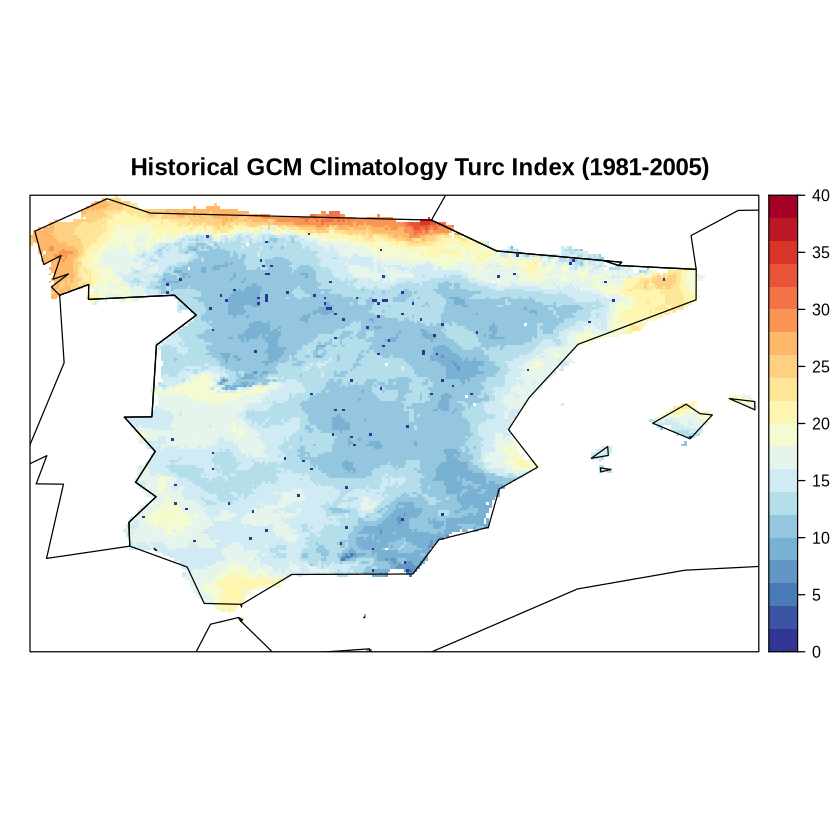

In [12]:
# HISTORICAL SCENARIO

# Get the list of historical chunk files
hist_files <- list.files(pattern = "Turc_DeepESD_Historical_.*\\.rds", full.names = TRUE)

# Initialize an empty list to store the light annual grids
hist_annual_list <- list()

message("--- Processing Historical Chunks ---")
for (i in seq_along(hist_files)) {
  
  # Load the heavy daily chunk
  temp_daily_grid <- readRDS(hist_files[i])
  
  # Aggregate to annual scale
  temp_annual_grid <- aggregateGrid(temp_daily_grid, aggr.y = list(FUN = "sum", na.rm = TRUE)) %>% 
    suppressMessages() %>% suppressWarnings()
  
  # Store the light annual grid
  hist_annual_list[[i]] <- temp_annual_grid
  
  # Clean memory
  rm(temp_daily_grid, temp_annual_grid)
  gc()
}

# Bind the much lighter annual grids together
message("Binding annual grids...")
hist_bound_annual <- do.call("bindGrid", c(hist_annual_list, list(dimension = "time")))

# Calculate the final climatology
message("Computing final climatology...")
hist_clim <- climatology(hist_bound_annual) %>% suppressMessages()

# Apply the NA masks to clean the map
y_dummy <- readRDS('y_template.rds')
attr(y_dummy$Data, "dimensions") <- c("time", "lat", "lon")
ocean_mask <- is.na(y_dummy$Data[1, , ])
capa_hist <- hist_clim$Data[1, , ]
capa_hist[ocean_mask] <- NA
capa_hist[capa_hist == 0] <- NA
hist_clim$Data[1, , ] <- capa_hist

# Plot
spatialPlot(hist_clim,
            color.theme = "RdYlBu",
            backdrop.theme = "countries",
            at = seq(0, 40, length.out = 21), 
            set.min = 0, set.max = 40,
            rev.colors = TRUE,
            main = "Historical GCM Climatology Turc Index (1981-2005)")


--- Processing Future Chunks ---

Binding annual grids...

Computing final climatology...



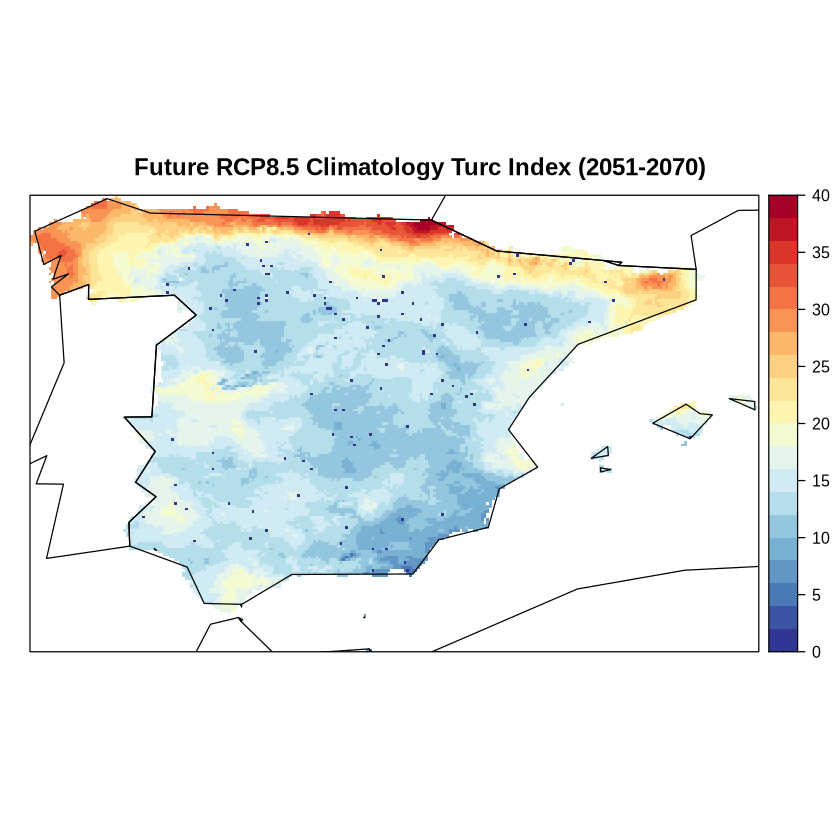

In [13]:
# FUTURE SCENARIO RCP8.5

# Get the list of future chunk files
fut_files <- list.files(pattern = "Turc_DeepESD_RCP85_.*\\.rds", full.names = TRUE)

fut_annual_list <- list()

message("\n--- Processing Future Chunks ---")
for (i in seq_along(fut_files)) {
  
  temp_daily_grid <- readRDS(fut_files[i])
  
  temp_annual_grid <- aggregateGrid(temp_daily_grid, aggr.y = list(FUN = "sum", na.rm = TRUE)) %>% 
    suppressMessages() %>% suppressWarnings()
  
  fut_annual_list[[i]] <- temp_annual_grid
  
  rm(temp_daily_grid, temp_annual_grid)
  gc()
}

# Bind the light annual grids
message("Binding annual grids...")
fut_bound_annual <- do.call("bindGrid", c(fut_annual_list, list(dimension = "time")))

# Calculate climatology
message("Computing final climatology...")
fut_clim <- climatology(fut_bound_annual) %>% suppressMessages()

# Apply masks
y_dummy <- readRDS('y_template.rds')
attr(y_dummy$Data, "dimensions") <- c("time", "lat", "lon")
ocean_mask <- is.na(y_dummy$Data[1, , ])
capa_hist <- fut_clim$Data[1, , ]
capa_hist[ocean_mask] <- NA
capa_hist[capa_hist == 0] <- NA
fut_clim$Data[1, , ] <- capa_hist

# Plot
spatialPlot(fut_clim, 
            color.theme = "RdYlBu",
            backdrop.theme = "countries",
            at = seq(0, 40, length.out = 21), 
            set.min = 0, set.max = 40,
            rev.colors = TRUE, 
            main = "Future RCP8.5 Climatology Turc Index (2051-2070)")

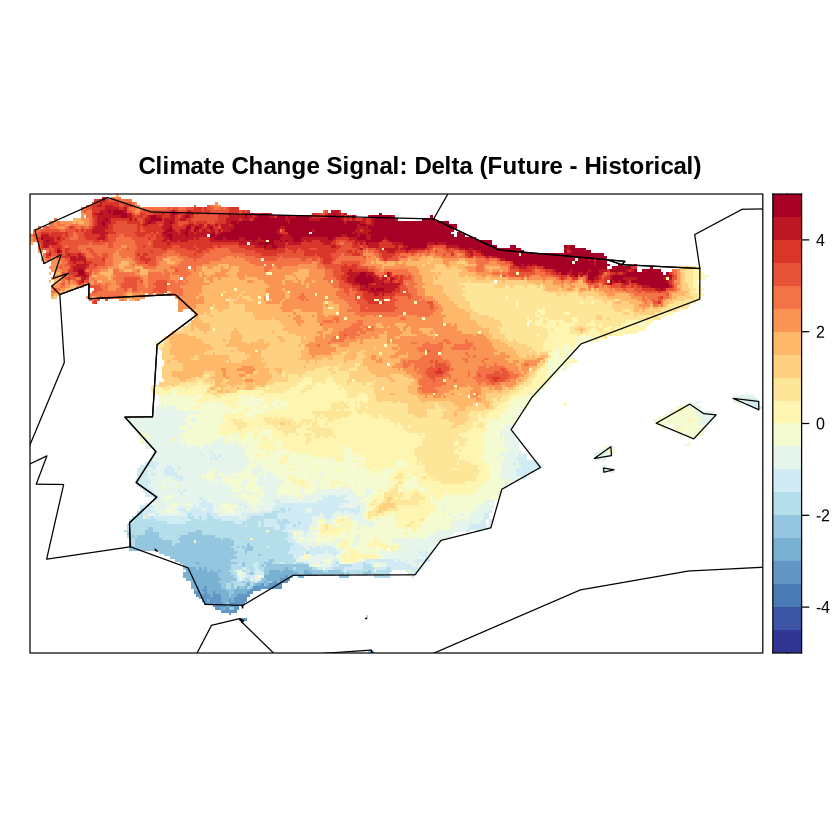

In [14]:
# --- DELTA CALCULATION (FUTURE - HISTORICAL) ---

# Subtract historical from future to get the absolute change
delta_clim <- gridArithmetics(fut_clim, hist_clim, operator = "-")

# Apply masks
y_dummy <- readRDS('y_template.rds')
attr(y_dummy$Data, "dimensions") <- c("time", "lat", "lon")
ocean_mask <- is.na(y_dummy$Data[1, , ])
capa_hist <- delta_clim$Data[1, , ]
capa_hist[ocean_mask] <- NA
capa_hist[capa_hist == 0] <- NA
delta_clim$Data[1, , ] <- capa_hist

# Plot
spatialPlot(delta_clim, 
            color.theme = "RdYlBu",
            backdrop.theme = "countries",
            at = seq(-5, 5, length.out = 21), 
            set.min = -5, set.max = 5,
            rev.colors = TRUE,
            main = "Climate Change Signal: Delta (Future - Historical)")

In [16]:
print(sessionInfo())

R version 4.5.3 (2026-03-11)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.3 LTS

Matrix products: default
BLAS/LAPACK: /home/lavinp/miniforge3/envs/turc-downscaling/lib/libopenblasp-r0.3.33.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] visualizeR_1.6.4       downscaleR.keras_1.1.1 downscaleR_3.3.4      
[4] transformeR_2.2.5      keras_2.16.1           tensorflow_2.20.0     
[7] reticulate_1.46.0     

loaded via a namespace (and not attached):
 [1] d